# Florida outage recovery exploration

Exploratory only.

This notebook uses the 10 event-county pairs from the toy GEE export as the master list,
pulls only the needed outage windows from `timeseries.pq`, joins the hourly weather export on
`event_id + geoid + datetime`, and ends with 10 dual-axis panels.

In [10]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.style.use("default")

POUS_PATH = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv")
TS_PATH = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq")
WEATHER_PATH = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\toy_tft_florida_event_weather_era5_hourly.csv")

PAD_BEFORE_HOURS = 12
PAD_AFTER_HOURS = 12
FL_STATE_FIPS = "12"
DATE_START = pd.Timestamp("2017-09-08")
DATE_END = pd.Timestamp("2017-09-18")

EVENTS = pd.DataFrame([
    {"event_id": "event_001", "geoid": "12075", "storm": "2017242N16333", "event_start": "2017-09-09 22:00", "duration_hours": 190},
    {"event_id": "event_002", "geoid": "12067", "storm": "2017242N16333", "event_start": "2017-09-09 20:00", "duration_hours": 191},
    {"event_id": "event_003", "geoid": "12079", "storm": "2017242N16333", "event_start": "2017-09-10 02:00", "duration_hours": 124},
    {"event_id": "event_004", "geoid": "12011", "storm": "2017242N16333", "event_start": "2017-09-10 06:00", "duration_hours": 178},
    {"event_id": "event_005", "geoid": "12086", "storm": "2017242N16333", "event_start": "2017-09-10 06:00", "duration_hours": 210},
    {"event_id": "event_006", "geoid": "12125", "storm": "2017242N16333", "event_start": "2017-09-10 11:00", "duration_hours": 133},
    {"event_id": "event_007", "geoid": "12111", "storm": "2017242N16333", "event_start": "2017-09-10 14:00", "duration_hours": 131},
    {"event_id": "event_008", "geoid": "12099", "storm": "2017242N16333", "event_start": "2017-09-10 14:00", "duration_hours": 147},
    {"event_id": "event_009", "geoid": "12021", "storm": "2017242N16333", "event_start": "2017-09-10 14:00", "duration_hours": 263},
    {"event_id": "event_010", "geoid": "12093", "storm": "2017242N16333", "event_start": "2017-09-10 16:00", "duration_hours": 175},
])
EVENTS["CountyFIPS"] = EVENTS["geoid"].astype("string").str.zfill(5)
EVENTS["event_start"] = pd.to_datetime(EVENTS["event_start"]).dt.floor("h")
EVENTS = EVENTS[["event_id", "geoid", "CountyFIPS", "storm", "event_start", "duration_hours"]]

print(f"Master event count: {len(EVENTS)}")
display(EVENTS)


Master event count: 10


,event_id,geoid,CountyFIPS,storm,event_start,duration_hours
0,event_001,12075,12075,2017242N16333,2017-09-09 22:00:00,190
1,event_002,12067,12067,2017242N16333,2017-09-09 20:00:00,191
2,event_003,12079,12079,2017242N16333,2017-09-10 02:00:00,124
3,event_004,12011,12011,2017242N16333,2017-09-10 06:00:00,178
4,event_005,12086,12086,2017242N16333,2017-09-10 06:00:00,210
5,event_006,12125,12125,2017242N16333,2017-09-10 11:00:00,133
6,event_007,12111,12111,2017242N16333,2017-09-10 14:00:00,131
7,event_008,12099,12099,2017242N16333,2017-09-10 14:00:00,147
8,event_009,12021,12021,2017242N16333,2017-09-10 14:00:00,263
9,event_010,12093,12093,2017242N16333,2017-09-10 16:00:00,175


In [11]:

def standardize_fips(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.zfill(5)


def standardize_hourly_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce").dt.floor("h")


def read_pous(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"event_start", "CountyFIPS", "storm"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"POUS.csv is missing columns: {sorted(missing)}")

    df = df.copy()
    df["CountyFIPS"] = standardize_fips(df["CountyFIPS"])
    df["event_start"] = standardize_hourly_datetime(df["event_start"])
    if "duration_hours" in df.columns:
        df["duration_hours"] = pd.to_numeric(df["duration_hours"], errors="coerce")

    df = df[
        df["CountyFIPS"].str.startswith(FL_STATE_FIPS)
        & df["event_start"].between(DATE_START, DATE_END)
    ].copy()
    return df.sort_values(["event_start", "CountyFIPS"])


def read_weather(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {
        "event_id", "geoid", "county", "datetime", "event_start", "duration_hours",
        "gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c",
    }
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Weather CSV is missing columns: {sorted(missing)}")

    df = df.copy()
    df["event_id"] = df["event_id"].astype("string").str.strip()
    df["geoid"] = standardize_fips(df["geoid"])
    df["datetime"] = standardize_hourly_datetime(df["datetime"])
    df["event_start"] = standardize_hourly_datetime(df["event_start"])
    df["duration_hours"] = pd.to_numeric(df["duration_hours"], errors="coerce")

    numeric_cols = ["gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["event_id", "geoid", "datetime"]).sort_values(["event_id", "geoid", "datetime"])
    return df


def load_outage_window(path: Path, county_fips: str, window_start: pd.Timestamp, window_end: pd.Timestamp) -> pd.DataFrame:
    county_fips = str(county_fips).zfill(5)
    dataset = ds.dataset(path, format="parquet")

    filt = (
        (ds.field("CountyFIPS") == county_fips)
        & (ds.field("RecordDateTime") >= pd.Timestamp(window_start))
        & (ds.field("RecordDateTime") <= pd.Timestamp(window_end))
    )

    table = dataset.to_table(
        filter=filt,
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"],
    )
    df = table.to_pandas()
    if "CountyFIPS" not in df.columns or "RecordDateTime" not in df.columns:
        df = df.reset_index()

    df = df.rename(columns={
        "RecordDateTime": "datetime",
        "OutageFraction": "outageFraction",
        "CustomersTracked": "customersTracked",
    })
    if "CountyFIPS" not in df.columns:
        raise KeyError(f"CountyFIPS missing after reset_index. Columns: {df.columns.tolist()}")
    if "datetime" not in df.columns:
        raise KeyError(f"datetime missing after reset_index. Columns: {df.columns.tolist()}")

    df["CountyFIPS"] = standardize_fips(df["CountyFIPS"])
    df["datetime"] = standardize_hourly_datetime(df["datetime"])
    df["outageFraction"] = pd.to_numeric(df["outageFraction"], errors="coerce")
    df["customersTracked"] = pd.to_numeric(df["customersTracked"], errors="coerce")
    return df[["datetime", "CountyFIPS", "outageFraction", "customersTracked"]].sort_values("datetime")


def build_event_bundle(event_row: dict, weather_df: pd.DataFrame):
    county_fips = str(event_row["CountyFIPS"]).zfill(5)
    event_id = str(event_row["event_id"])
    event_start = pd.to_datetime(event_row["event_start"]).floor("h")
    duration_hours = float(event_row["duration_hours"])

    window_start = event_start - pd.Timedelta(hours=PAD_BEFORE_HOURS)
    window_end = event_start + pd.Timedelta(hours=max(duration_hours, 24) + PAD_AFTER_HOURS)

    outage = load_outage_window(TS_PATH, county_fips, window_start, window_end)
    weather_sub = weather_df[(weather_df["event_id"] == event_id) & (weather_df["geoid"] == county_fips)].copy()
    weather_sub = weather_sub.sort_values("datetime")

    merged = outage.merge(
        weather_sub[["datetime", "gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c"]],
        on="datetime",
        how="inner",
    ).sort_values("datetime")

    return {
        **event_row,
        "county_fips": county_fips,
        "window_start": window_start,
        "window_end": window_end,
        "outage": outage,
        "weather": weather_sub,
        "merged": merged,
    }


def plot_event(ax, bundle: dict):
    merged = bundle["merged"]
    title = f'{bundle["event_id"]} | county={bundle["county_fips"]} | start={bundle["event_start"]:%Y-%m-%d %H:%M}'

    if merged.empty:
        ax.text(0.5, 0.5, "No merged data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        return

    ax2 = ax.twinx()
    left = ax.plot(
        merged["datetime"],
        merged["outageFraction"],
        color="tab:orange",
        linewidth=2.0,
        label="outageFraction",
    )
    right = ax2.plot(
        merged["datetime"],
        merged["gust_mps"],
        color="tab:blue",
        linewidth=1.6,
        label="gust_mps",
    )

    ax.axvline(bundle["event_start"], color="gray", linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("datetime")
    ax.set_ylabel("outageFraction", color="tab:orange")
    ax2.set_ylabel("gust_mps", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    lines = left + right
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, loc="upper left", fontsize=8)


In [12]:

pous = read_pous(POUS_PATH)
weather = read_weather(WEATHER_PATH)

pous_subset = pous[
    pous["CountyFIPS"].isin(EVENTS["CountyFIPS"])
    & pous["event_start"].between(DATE_START, DATE_END)
].copy()

print(f"POUS subset rows in Florida window: {len(pous_subset)}")
display(pous_subset[[c for c in ["event_start", "CountyFIPS", "storm", "duration_hours"] if c in pous_subset.columns]].head(20))

bundles = []
coverage_rows = []
for row in EVENTS.to_dict("records"):
    bundle = build_event_bundle(row, weather)
    bundles.append(bundle)
    coverage_rows.append({
        "event_id": bundle["event_id"],
        "CountyFIPS": bundle["county_fips"],
        "storm": bundle["storm"],
        "event_start": bundle["event_start"],
        "outage_rows": len(bundle["outage"]),
        "weather_rows": len(bundle["weather"]),
        "merged_rows": len(bundle["merged"]),
        "status": "ok" if len(bundle["merged"]) > 0 else "missing",
    })

coverage = pd.DataFrame(coverage_rows)
print(f"Matched event bundles: {len(bundles)} of {len(EVENTS)}")
display(coverage)

missing = coverage[coverage["merged_rows"] == 0]
if not missing.empty:
    print("Events with no merged rows:")
    display(missing[["event_id", "CountyFIPS", "storm", "event_start", "outage_rows", "weather_rows"]])


POUS subset rows in Florida window: 10


,event_start,CountyFIPS,storm,duration_hours
38,2017-09-09 20:00:00,12067,2017242N16333,191
40,2017-09-09 22:00:00,12075,2017242N16333,190
44,2017-09-10 02:00:00,12079,2017242N16333,124
45,2017-09-10 06:00:00,12011,2017242N16333,178
46,2017-09-10 06:00:00,12086,2017242N16333,210
47,2017-09-10 11:00:00,12125,2017242N16333,133
52,2017-09-10 14:00:00,12021,2017242N16333,263
51,2017-09-10 14:00:00,12099,2017242N16333,147
50,2017-09-10 14:00:00,12111,2017242N16333,131
57,2017-09-10 16:00:00,12093,2017242N16333,175


Matched event bundles: 10 of 10


,event_id,CountyFIPS,storm,event_start,outage_rows,weather_rows,merged_rows,status
0,event_001,12075,2017242N16333,2017-09-09 22:00:00,215,214,214,ok
1,event_002,12067,2017242N16333,2017-09-09 20:00:00,216,215,215,ok
2,event_003,12079,2017242N16333,2017-09-10 02:00:00,149,148,148,ok
3,event_004,12011,2017242N16333,2017-09-10 06:00:00,203,202,202,ok
4,event_005,12086,2017242N16333,2017-09-10 06:00:00,235,234,234,ok
5,event_006,12125,2017242N16333,2017-09-10 11:00:00,158,157,157,ok
6,event_007,12111,2017242N16333,2017-09-10 14:00:00,156,155,155,ok
7,event_008,12099,2017242N16333,2017-09-10 14:00:00,172,171,171,ok
8,event_009,12021,2017242N16333,2017-09-10 14:00:00,288,287,287,ok
9,event_010,12093,2017242N16333,2017-09-10 16:00:00,200,199,199,ok


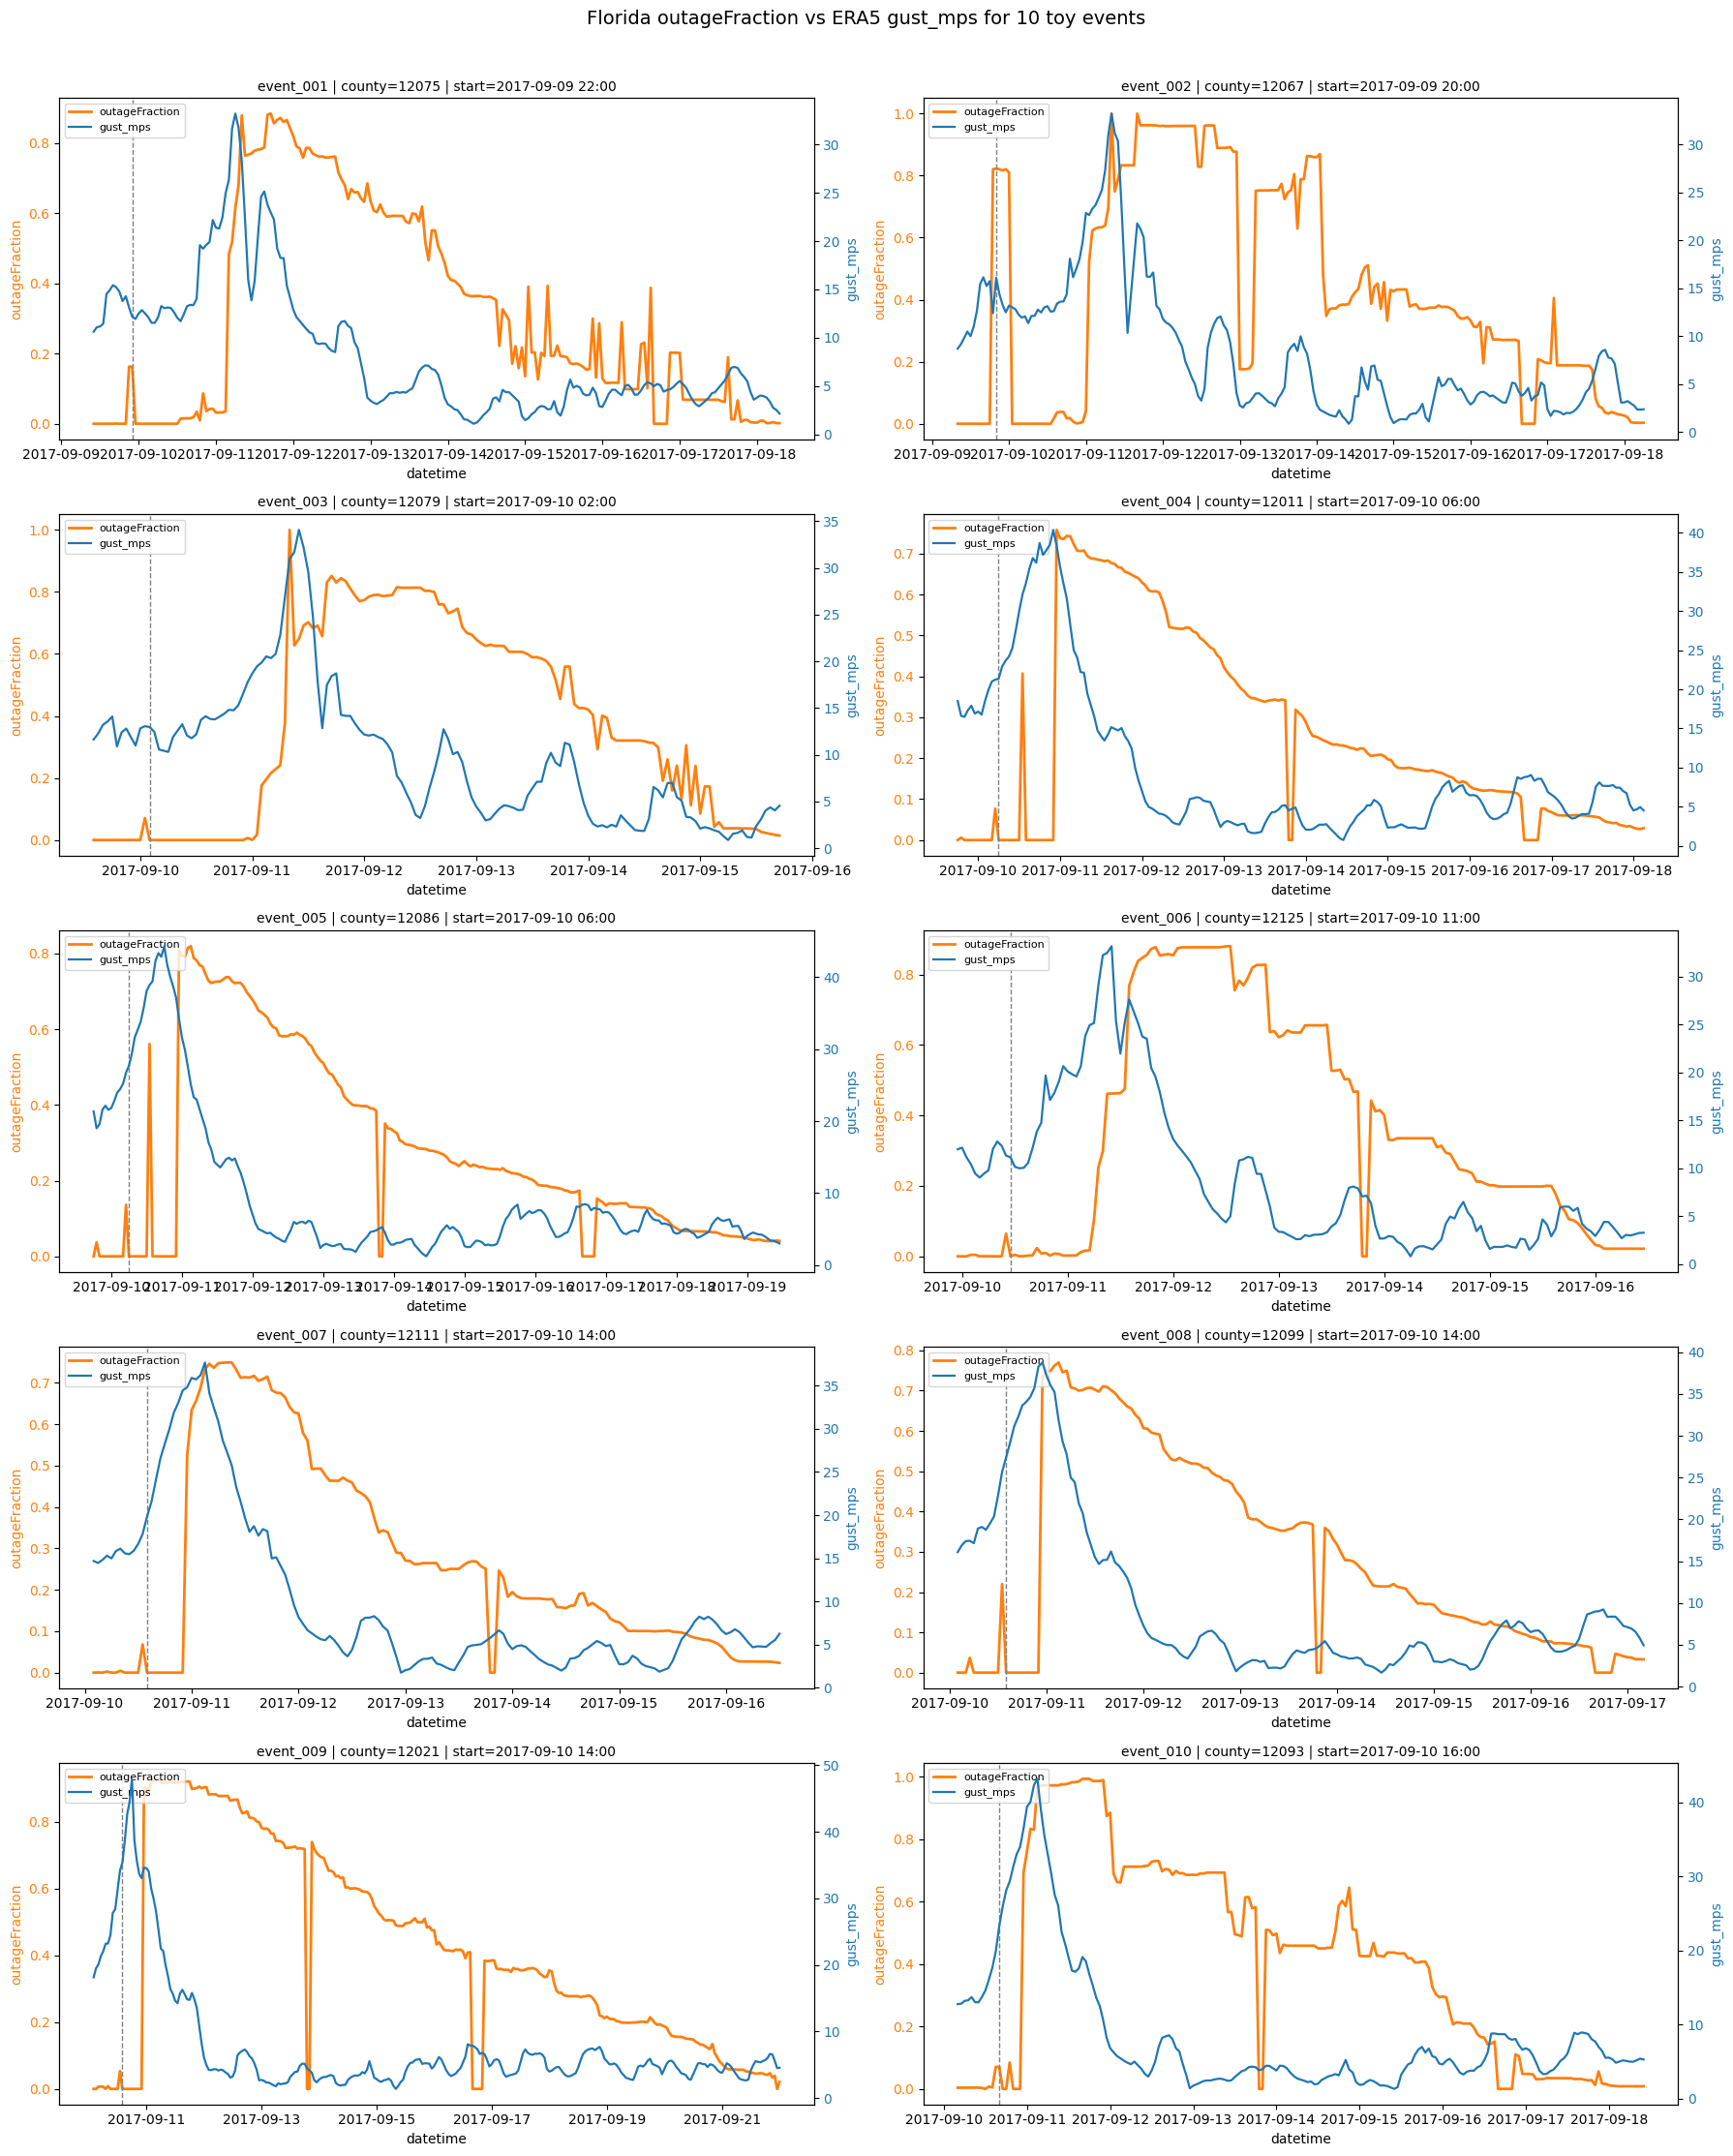

Plotted 10 events.


In [13]:

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.ravel()

for ax, bundle in zip(axes, bundles):
    plot_event(ax, bundle)

for ax in axes[len(bundles):]:
    ax.axis("off")

fig.suptitle("Florida outageFraction vs ERA5 gust_mps for 10 toy events", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

print(f"Plotted {len(bundles)} events.")


next step: compute cross-correlation between gust and outageFraction for each county to estimate the lag distribution. That will quantify what you are visually seeing here.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def best_lag_hours(df, max_lag=72, min_points=24):
    x = df[["datetime", "outageFraction", "gust_mps"]].copy()
    x["datetime"] = pd.to_datetime(x["datetime"], errors="coerce")
    x = x.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")

    # Make the hourly grid explicit.
    x = x.resample("1h").mean()
    x = x.interpolate("time").ffill().bfill()

    x = x[["outageFraction", "gust_mps"]].dropna()
    if len(x) < min_points:
        return np.nan, np.nan, len(x)

    gust = x["gust_mps"]
    outage = x["outageFraction"]

    gust_std = gust.std(ddof=0)
    outage_std = outage.std(ddof=0)
    if gust_std == 0 or outage_std == 0:
        return np.nan, np.nan, len(x)

    gust_z = (gust - gust.mean()) / gust_std
    outage_z = (outage - outage.mean()) / outage_std

    best_lag = np.nan
    best_corr = -np.inf

    for lag in range(-max_lag, max_lag + 1):
        # Positive lag means gust leads outage by lag hours.
        aligned = pd.concat([gust_z.shift(lag), outage_z], axis=1).dropna()
        if len(aligned) < min_points:
            continue

        corr = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])
        if pd.notna(corr) and corr > best_corr:
            best_corr = corr
            best_lag = lag

    return best_lag, best_corr, len(x)

In [15]:
def merge_outage_weather(outage_df, weather_df, event_row):
    """
    Merge outage and weather data for one event-county pair.

    Expected canonical columns:
      outage_df: datetime, CountyFIPS, outageFraction, customersTracked
      weather_df: event_id, geoid, datetime, gust_mps, wind_speed_mps, precip_mm, pressure_hpa, temp_c
    """
    if outage_df.empty:
        return pd.DataFrame()

    event_id = str(event_row["event_id"])
    county_fips = str(event_row["CountyFIPS"]).zfill(5)
    event_start = pd.to_datetime(event_row["event_start"], errors="coerce")

    w = weather_df.copy()
    w["event_id"] = w["event_id"].astype(str)
    w["geoid"] = w["geoid"].astype(str).str.zfill(5)
    w["datetime"] = pd.to_datetime(w["datetime"], errors="coerce").dt.floor("h")

    o = outage_df.copy()
    o["CountyFIPS"] = o["CountyFIPS"].astype(str).str.zfill(5)
    o["datetime"] = pd.to_datetime(o["datetime"], errors="coerce").dt.floor("h")

    w = w[
        (w["event_id"] == event_id) &
        (w["geoid"] == county_fips)
    ].copy()

    if event_start is not None and pd.notna(event_start):
        # Optional sanity filter. Keeps the weather window around the event.
        w = w[w["datetime"].between(event_start - pd.Timedelta(hours=48),
                                    event_start + pd.Timedelta(hours=400))]

    merged = o.merge(
        w,
        left_on=["CountyFIPS", "datetime"],
        right_on=["geoid", "datetime"],
        how="inner",
        suffixes=("_outage", "_weather"),
    )

    if merged.empty:
        return merged

    # Keep a compact, predictable column order.
    cols = [
        "event_id", "storm", "CountyFIPS", "geoid", "datetime",
        "outageFraction", "customersTracked",
        "gust_mps", "wind_speed_mps", "precip_mm", "pressure_hpa", "temp_c",
        "event_start", "duration_hours",
    ]
    keep = [c for c in cols if c in merged.columns]
    return merged[keep].sort_values("datetime").reset_index(drop=True)

Events in master list: 10


,event_id,CountyFIPS,storm,outage_rows,merged_rows,has_merged_data
0,event_002,12067,2017242N16333,216,215,True
1,event_001,12075,2017242N16333,215,214,True
2,event_003,12079,2017242N16333,149,148,True
3,event_004,12011,2017242N16333,203,202,True
4,event_005,12086,2017242N16333,235,234,True
5,event_006,12125,2017242N16333,158,157,True
6,event_007,12111,2017242N16333,156,155,True
7,event_008,12099,2017242N16333,172,171,True
8,event_009,12021,2017242N16333,288,287,True
9,event_010,12093,2017242N16333,200,199,True


Lag estimates:


,event_id,CountyFIPS,storm,best_lag_hours,peak_corr,n_hours
6,event_007,12111,2017242N16333,20,0.844191,155
2,event_003,12079,2017242N16333,30,0.638246,148
5,event_006,12125,2017242N16333,31,0.779600,157
3,event_004,12011,2017242N16333,38,0.793791,202
4,event_005,12086,2017242N16333,41,0.798765,234
8,event_009,12021,2017242N16333,41,0.654146,287
1,event_001,12075,2017242N16333,42,0.760831,214
7,event_008,12099,2017242N16333,42,0.813077,171
9,event_010,12093,2017242N16333,47,0.643682,199
0,event_002,12067,2017242N16333,62,0.667027,215


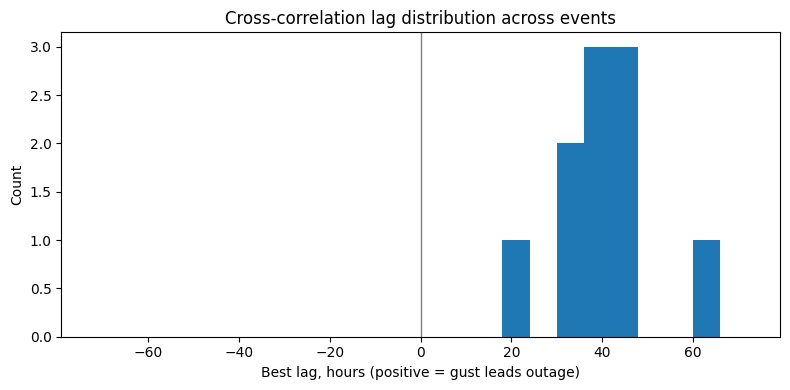

In [16]:
event_master = (
    weather[["event_id", "storm", "geoid", "event_start", "duration_hours"]]
    .drop_duplicates()
    .rename(columns={"geoid": "CountyFIPS"})
)
event_master["CountyFIPS"] = event_master["CountyFIPS"].astype(str).str.zfill(5)
event_master["event_start"] = pd.to_datetime(event_master["event_start"], errors="coerce")
event_master["duration_hours"] = pd.to_numeric(event_master["duration_hours"], errors="coerce")
event_master = event_master.dropna(subset=["CountyFIPS", "event_start", "event_id"]).sort_values(["event_start", "event_id"])

lag_rows = []
coverage_rows = []

for row in event_master.to_dict("records"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.to_datetime(row["event_start"])

    duration_hours = row.get("duration_hours")
    if pd.isna(duration_hours) or float(duration_hours) <= 0:
        duration_hours = 24.0
    else:
        duration_hours = float(duration_hours)

    window_start = event_start - pd.Timedelta(hours=PAD_BEFORE_HOURS)
    window_end = event_start + pd.Timedelta(hours=max(duration_hours, 24.0) + PAD_AFTER_HOURS)

    outage = load_outage_window(TS_PATH, county_fips, window_start, window_end)
    merged = merge_outage_weather(outage, weather, row)

    coverage_rows.append({
        "event_id": str(row["event_id"]),
        "CountyFIPS": county_fips,
        "storm": str(row.get("storm", "")),
        "outage_rows": len(outage),
        "merged_rows": len(merged),
        "has_merged_data": not merged.empty,
    })

    if merged.empty:
        lag_rows.append({
            "event_id": str(row["event_id"]),
            "CountyFIPS": county_fips,
            "storm": str(row.get("storm", "")),
            "best_lag_hours": np.nan,
            "peak_corr": np.nan,
            "n_hours": 0,
        })
        continue

    lag_hours, peak_corr, n_hours = best_lag_hours(merged, max_lag=72, min_points=24)
    lag_rows.append({
        "event_id": str(row["event_id"]),
        "CountyFIPS": county_fips,
        "storm": str(row.get("storm", "")),
        "best_lag_hours": lag_hours,
        "peak_corr": peak_corr,
        "n_hours": n_hours,
    })

coverage_df = pd.DataFrame(coverage_rows)
lag_df = pd.DataFrame(lag_rows)

print(f"Events in master list: {len(event_master)}")
display(coverage_df)

print("Lag estimates:")
display(lag_df.sort_values(["best_lag_hours", "event_id"]))

valid_lags = lag_df["best_lag_hours"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_lags, bins=range(-72, 73, 6))
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Best lag, hours (positive = gust leads outage)")
ax.set_ylabel("Count")
ax.set_title("Cross-correlation lag distribution across events")
plt.tight_layout()
plt.show()

“gust” = the full continuous gust_mps time series
“outage” = the full continuous outageFraction time series
both were standardized (z-scored) and then cross-correlated over lags

So the method is:
corr(gust(t−τ),outage(t))

and it picks the lag τ that maximizes correlation.

No event detection. No thresholding. No “peak picking”.

Why this disagrees with your visual impression:

You are visually tracking onset timing:

gust spikes
outage starts rising shortly after (hours)

Cross-correlation is tracking shape alignment:

outageFraction rises and then stays high for a long time
gust decays quickly
the best statistical alignment happens when the bulk of outage overlaps the earlier gust period
That pushes the optimal lag to ~30–45 hours.

So:

Visual: “when does outage start reacting?” → small lag (hours)
Cross-corr: “when do the curves align best overall?” → larger lag (day-scale)
These are different quantities.